# Voisins Piezos 

Recherche de Piezos proche géographiquement et/ou appartenant à la même couche géologique.

Upload de catalogue pizeo depuis la database de BQ.

## 0. Params et Setup

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import pandas as pd
from google.cloud import bigquery

from hydrosense.params import *

/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.6) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## 2. TesT du chargement des données

Les informations stockées dans le fichier .env et qui sont mise à disposition grâce au module params.py

In [4]:
TABLE = "cat_piezo_interm"
GCP_PROJECT_ID,BQ_DATASET_ID,TABLE
MIN_COMPLETUDE = 0.8

bss_id = 'BSS001QHYH' # target of the day !

client = bigquery.Client(project=GCP_PROJECT_ID)

In [5]:
query = f"""
            SELECT *
            FROM `{GCP_PROJECT_ID}.{BQ_DATASET_ID}.{TABLE}`
            WHERE taux_completude > {MIN_COMPLETUDE}
        """
try:
    query_job = client.query(query)
    result = query_job.result()
    cat_clean = result.to_dataframe()
except:
    print("Not uploaded from Big Query")

/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


### 1.0 Isoler le code BDLisa du piezo target.

In [6]:
from hydrosense.utils.geo import calc_dist

# Récupérer les codes BD Lisa de la target
target_row = cat_clean[cat_clean['bss_id'] == bss_id]

raw_target_codes = target_row['codes_bdlisa'].values[0]
set_target_codes = set([c.strip() for c in str(raw_target_codes).split(',') if c.strip()])
print(f"Target {bss_id} - Codes géologiques : {set_target_codes}")

lat_target = target_row['y'].values[0]
lon_target = target_row['x'].values[0]

Target BSS001QHYH - Codes géologiques : {'352AC01'}


#### Fonction intersection géologique

In [7]:
def a_une_couche_commune(vignette_codes, target_codes):
    if pd.isna(vignette_codes) or not vignette_codes:
        return False
    # Transformation des codes du voisin en set
    set_voisin = set([c.strip() for c in str(vignette_codes).split(',') if c.strip()])
    # True si au moins un code est commun
    return len(target_codes.intersection(set_voisin)) > 0

In [33]:
#### Filtrer le catalogue sur la même couche géologique

In [9]:
df_meme_geologie = cat_clean[
    (cat_clean['bss_id'] != bss_id) &
    (cat_clean['codes_bdlisa'].apply(lambda x: a_une_couche_commune(x, set_target_codes)))
                            ].copy()

print(f"Found {len(df_meme_geologie)} voisins partageant la même géologie.")


df_meme_geologie['distance_km'] = df_meme_geologie.apply(
    lambda row: calc_dist(lat_target, lon_target, row['y'], row['x']), axis=1
                                                    )

top_10_voisins = df_meme_geologie.nsmallest(10, 'distance_km')
print("\n🏆 Top 10 des voisins géologiques les plus proches :")
print(top_10_voisins[['bss_id', 'distance_km', 'codes_bdlisa', 'date_debut_mesure','date_fin_mesure']])

Found 41 voisins partageant la même géologie.

🏆 Top 10 des voisins géologiques les plus proches :
          bss_id  distance_km codes_bdlisa         date_debut_mesure  \
2010  BSS001QHPU     7.686971      352AC01 1993-05-12 00:00:00+00:00   
2012  BSS001QJMK     9.853626      352AC01 1992-03-30 00:00:00+00:00   
423   BSS001QGLU    16.925575      352AC01 1993-04-21 00:00:00+00:00   
2013  BSS001QJSX    18.795035      352AC01 1991-08-26 00:00:00+00:00   
420   BSS001QGLS    19.440282      352AC01 1992-06-11 00:00:00+00:00   
321   BSS001RMFT    23.041868      352AC01 1995-05-30 00:00:00+00:00   
304   BSS001QJUZ    23.878520      352AC01 1992-06-11 00:00:00+00:00   
300   BSS001RMZT    29.732116      352AC01 2011-01-31 00:00:00+00:00   
322   BSS001RLGY    32.758815      352AC01 2010-01-05 00:00:00+00:00   
422   BSS001QHHN    33.168654      352AC01 2011-12-15 00:00:00+00:00   

               date_fin_mesure  
2010 2026-05-27 00:00:00+00:00  
2012 2026-05-28 00:00:00+00:00  
423  2026

### 1.0 Compter le nb de voisins pour tout les piezos de notre liste de piezometres.



In [10]:
# # Test avec les fonctions maisons.
for bss in TARGETS_BSS[:]:

    pass
    # info = info_piezo(bss)
    # departement = str(info['code_departement'].iloc[0])
    # print('Departement du piezo : ',departement)


### Process de creation des mutli-piezo

Pour l'instant le piezo target n'a pas été téléchargé.
Les fonctions de base peuvent le télécharger sous la forme classique.

In [11]:
from hydrosense.preprocess.cleaning import clean_piezo
from hydrosense.database.bigquery import load_piezo_bq

import matplotlib.pyplot as plt

In [12]:
df = load_piezo_bq(bss_id = bss_id )
df_clean = clean_piezo(df)
df_clean

BSS001QHYH : 14532 lignes chargées
Trou de 224 jours détecté ! 2751 lignes supprimées.
DataFrame final : 1994-01-18 00:00:00 → 2026-05-30 00:00:00 | 11821 jours


,date_mesure,niveau_nappe_eau
0,1994-01-18,14.20
1,1994-01-19,14.20
2,1994-01-20,14.13
3,1994-01-21,14.07
4,1994-01-22,14.00
...,...,...
11816,2026-05-26,12.00
11817,2026-05-27,11.96
11818,2026-05-28,11.93
11819,2026-05-29,11.89


BSS001QHPU : 12002 lignes chargées
BSS001QJMK : 12034 lignes chargées
BSS001QGLU : 11839 lignes chargées
BSS001QJSX : 12552 lignes chargées
BSS001QGLS : 11995 lignes chargées
BSS001RMFT : 11075 lignes chargées
BSS001QJUZ : 11854 lignes chargées
BSS001RMZT : 5426 lignes chargées
BSS001RLGY : 5679 lignes chargées
BSS001QHHN : 5281 lignes chargées


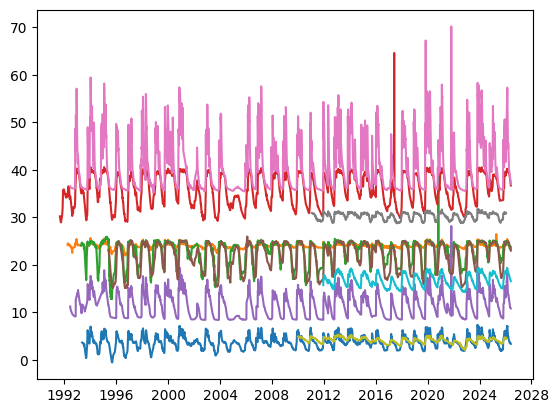

In [15]:
for id in top_10_voisins['bss_id'].values:
    df_voisin = load_piezo_bq(bss_id = id )
    plt.plot(df_voisin['date_mesure'],df_voisin['niveau_nappe_eau'])


🔄 Récupération et alignement des voisins...
BSS001QHPU : 12002 lignes chargées
BSS001QJMK : 12034 lignes chargées
BSS001QGLU : 11839 lignes chargées
BSS001QJSX : 12552 lignes chargées
BSS001QGLS : 11995 lignes chargées
BSS001RMFT : 11075 lignes chargées
BSS001QJUZ : 11854 lignes chargées
BSS001RMZT : 5426 lignes chargées
BSS001RLGY : 5679 lignes chargées
BSS001QHHN : 5281 lignes chargées
📊 Dimensions de la matrice fusionnée : (12696, 10)
⚠️ Pourcentage de valeurs manquantes : 21.4%
🧠 Imputation intelligente des trous...


/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


📉 Calcul de l'ACP...
✅ Variance expliquée par les 3 axes : 95.1%


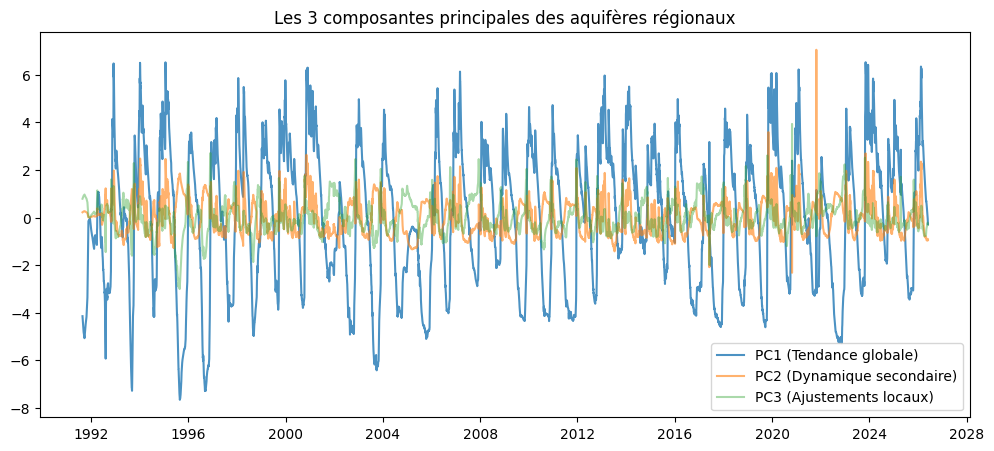

In [ ]:
import pandas as pd
import numpy as np

from sklearn.experimental import enable_iterative_imputer  # Requis pour activer IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("🔄 Récupération et alignement des voisins...")
series_list = []

# 1. ALIGNEMENT TEMPOREL
for id in top_10_voisins['bss_id'].values:
    df_voisin = load_piezo_bq(bss_id=id)
    df_voisin['date_mesure'] = pd.to_datetime(df_voisin['date_mesure']).dt.normalize()

    # On indexe par la date et on isole la chronique, renommée avec le code BSS
    s_voisin = df_voisin.set_index('date_mesure')['niveau_nappe_eau'].rename(id)
    series_list.append(s_voisin)

# pd.concat avec axis=1 va fusionner toutes les séries sur le même index de dates.
# Là où un voisin n'a pas de donnée, Pandas mettra un NaN.
df_wide = pd.concat(series_list, axis=1)

# (Optionnel) Restreindre la période d'étude si elle est trop large (ex: 2010-2024)
# df_wide = df_wide.loc['2010-01-01':'2024-01-01']

print(f"📊 Dimensions de la matrice fusionnée : {df_wide.shape}")
print(f"⚠️ Pourcentage de valeurs manquantes : {(df_wide.isna().sum().sum() / df_wide.size * 100):.1f}%")

print("🧠 Imputation intelligente des trous...")
# L'imputeur utilise un modèle (Ridge par défaut) pour estimer les NaNs de chaque colonne
# en fonction des autres colonnes. Parfait pour des nappes de la même couche !
imputer = IterativeImputer(max_iter=10, random_state=42)
matrice_imputee = imputer.fit_transform(df_wide)
df_imputed = pd.DataFrame(matrice_imputee, index=df_wide.index, columns=df_wide.columns)

# 3. STANDARDISATION ET ACP
print("📉 Calcul de l'ACP...")
# Très important : les niveaux (m NGF) ont des amplitudes différentes. Il faut standardiser.
scaler = StandardScaler()
matrice_scaled = scaler.fit_transform(df_imputed)

# Application de la PCA à 3 composantes
pca = PCA(n_components=3)
matrice_pca = pca.fit_transform(matrice_scaled)
df_pca = pd.DataFrame(matrice_pca,
                      index=df_wide.index,
                      columns=['PC1_hydro', 'PC2_hydro', 'PC3_hydro'])

print(f"✅ Variance expliquée par les 3 axes : {pca.explained_variance_ratio_.sum() * 100:.1f}%")
plt.figure(figsize=(12, 5))
plt.plot(df_pca.index, df_pca['PC1_hydro'], label='PC1', alpha=0.8)
plt.plot(df_pca.index, df_pca['PC2_hydro'], label='PC2', alpha=0.6)
plt.plot(df_pca.index, df_pca['PC3_hydro'], label='PC3', alpha=0.4)
plt.title("Les 3 composantes principales des aquifères régionaux")
plt.legend()
plt.show()

In [32]:
df_pca.var(axis = 0), pca.explained_variance_

(PC1_hydro    8.555902
 PC2_hydro    0.536950
 PC3_hydro    0.414483
 dtype: float64,
 array([8.5559017 , 0.5369505 , 0.41448291]))

<Axes: xlabel='PC1_hydro', ylabel='niveau_nappe_eau'>

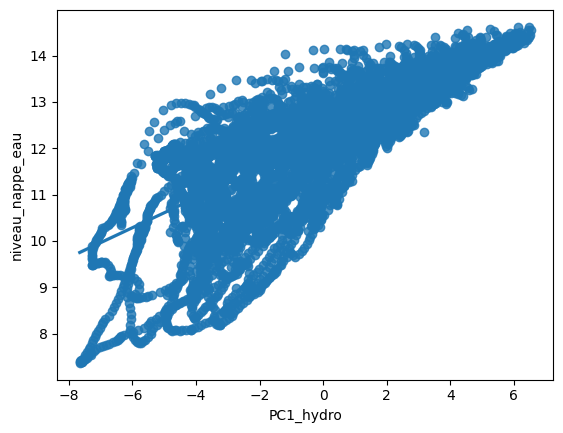

In [ ]:
df_wide.index.diff().unique()

df_comp = df_clean.merge(df_pca, how='left', on='date_mesure')


import seaborn as sns
sns.regplot(df_comp, x = 'PC1_hydro', y = 'niveau_nappe_eau')


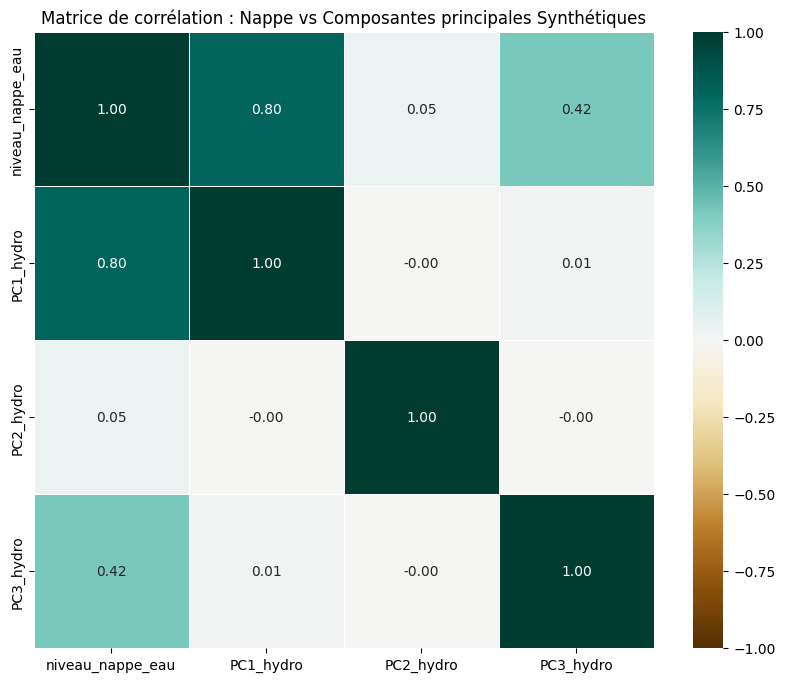

In [28]:
cols_to_corr = ['niveau_nappe_eau', 'PC1_hydro', 'PC2_hydro','PC3_hydro']
corr_mat = df_comp[cols_to_corr].corr()

plt.figure(figsize=(10, 8))

# 3. Création de la Heatmap
sns.heatmap(
    corr_mat,
    vmin=-1,
    vmax=1,
    cmap='BrBG',
    linewidths=.5,
    annot=True,
    annot_kws={"size": 10},
    fmt=".2f" # Pour limiter à 2 décimales et garder la lisibilité
)

plt.title("Matrice de corrélation : Nappe vs Composantes principales Synthétiques")
plt.show()

## 4. Upload de catalogue piezo

Catalogue des métadonnées des stations du réseau Ades

In [11]:
from hydrosense.database.ades import GestionnairePiezometrie
from hydrosense.database.entite import Entite

In [12]:
extracteur = Entite()
extracteur.total_stations(nb_mesures_piezo_min = 360)

Nombre total de stations trouvées : 5025


In [13]:
liste_piezo = extracteur.rechercher_stations(nb_mesures_piezo_min = 360, taille_max= 20_000)
df = extracteur.generer_df()

Recherche des stations avec les paramètres : {'format': 'json', 'size': 20000, 'nb_mesures_piezo_min': 360}...
-> 5025 stations trouvées !
df en entrée :  Index(['code_bss', 'urn_bss', 'date_debut_mesure', 'date_fin_mesure',
       'code_commune_insee', 'nom_commune', 'x', 'y', 'codes_bdlisa',
       'urns_bdlisa', 'geometry', 'bss_id', 'altitude_station',
       'nb_mesures_piezo', 'code_departement', 'nom_departement', 'libelle_pe',
       'profondeur_investigation', 'codes_masse_eau_edl', 'noms_masse_eau_edl',
       'urns_masse_eau_edl', 'date_maj'],
      dtype='object')


/home/charourou/projects/Projet_Hydrosense/hydrosense/database/entite.py:133: FutureWarning: Parsing 'CEST' as tzlocal (dependent on system timezone) is deprecated and will raise in a future version. Pass the 'tz' keyword or call tz_localize after construction instead
  return pd.to_datetime(str(valeur), utc=True)
/home/charourou/projects/Projet_Hydrosense/hydrosense/database/entite.py:133: FutureWarning: Parsing 'CET' as tzlocal (dependent on system timezone) is deprecated and will raise in a future version. Pass the 'tz' keyword or call tz_localize after construction instead
  return pd.to_datetime(str(valeur), utc=True)


df en sortie :  Index(['altitude_station', 'bss_id', 'code_bss', 'code_commune_insee',
       'code_departement', 'codes_bdlisa', 'codes_masse_eau_edl',
       'date_debut_mesure', 'date_fin_mesure', 'date_maj', 'geometry',
       'libelle_pe', 'nb_mesures_piezo', 'nom_commune', 'nom_departement',
       'noms_masse_eau_edl', 'profondeur_investigation', 'urn_bss',
       'urns_bdlisa', 'urns_masse_eau_edl', 'x', 'y'],
      dtype='object')
-> Catalogue structuré en DataFrame (5025 lignes, 22 colonnes).


In [10]:
df.head()

,altitude_station,bss_id,code_bss,code_commune_insee,code_departement,codes_bdlisa,codes_masse_eau_edl,date_debut_mesure,date_fin_mesure,date_maj,...,nb_mesures_piezo,nom_commune,nom_departement,noms_masse_eau_edl,profondeur_investigation,urn_bss,urns_bdlisa,urns_masse_eau_edl,x,y
0,61.29,BSS002PJXA,12288X0089/PIEZO.,97416,974,974AT01,LG106,1996-11-13 00:00:00+00:00,2026-05-26 00:00:00+00:00,NaT,...,8740,Saint-Pierre,La Réunion,Formations volcaniques et volcano-sédimentaire...,200.00,http://services.ades.eaufrance.fr/pointeau/122...,http://reseau.eaufrance.fr/geotraitements/bdli...,[http://www.sandre.eaufrance.fr/geo/MasseDEauS...,55.459616,-21.317968
1,179.2,BSS000YWFY,03423X0020/100,68113,68,221AA17,CG101,1954-11-08 00:00:00+00:00,1988-12-27 00:00:00+00:00,NaT,...,1582,Guémar,Haut-Rhin,"Nappe d’Alsace, Pliocène de Haguenau et Oligocène",11.00,http://services.ades.eaufrance.fr/pointeau/034...,http://reseau.eaufrance.fr/geotraitements/bdli...,[http://www.sandre.eaufrance.fr/geo/MasseDEauS...,7.396859,48.190279
2,174.0,BSS000YWHH,03423X0056/100,68113,68,221AA15,CG101,1954-11-08 00:00:00+00:00,2026-05-23 00:00:00+00:00,NaT,...,5158,Guémar,Haut-Rhin,"Nappe d’Alsace, Pliocène de Haguenau et Oligocène",10.70,http://services.ades.eaufrance.fr/pointeau/034...,http://reseau.eaufrance.fr/geotraitements/bdli...,[http://www.sandre.eaufrance.fr/geo/MasseDEauS...,7.396716,48.190195
3,179.7,BSS000YZZR,03428X0021/200,67281,67,221AA17,CG101,1954-04-24 00:00:00+00:00,1974-04-02 00:00:00+00:00,NaT,...,994,Marckolsheim,Bas-Rhin,"Nappe d’Alsace, Pliocène de Haguenau et Oligocène",3.60,http://services.ades.eaufrance.fr/pointeau/034...,http://reseau.eaufrance.fr/geotraitements/bdli...,[http://www.sandre.eaufrance.fr/geo/MasseDEauS...,7.542952,48.134318
4,-999.0,BSS001TULG,07011X0117/RN00,01039,01,712AH37,None,2014-07-01 00:00:00+00:00,2016-09-02 00:00:00+00:00,NaT,...,795,Béon,Ain,None,1.63,http://services.ades.eaufrance.fr/pointeau/070...,http://reseau.eaufrance.fr/geotraitements/bdli...,[],5.757082,45.847673


In [11]:
df['date_fin_mesure'].sort_values()

169    1964-06-04 00:00:00+00:00
1820   1965-09-23 00:00:00+00:00
2340   1967-01-31 00:00:00+00:00
2486   1967-01-31 00:00:00+00:00
1685   1967-06-27 00:00:00+00:00
                  ...           
234    2026-05-29 00:00:00+00:00
3753   2026-05-29 00:00:00+00:00
3000   2026-05-29 00:00:00+00:00
1341   2026-05-29 00:00:00+00:00
1794   2026-05-30 00:00:00+00:00
Name: date_fin_mesure, Length: 5025, dtype: datetime64[ns, UTC]

Issue with dtype: datetime64[ns, UTC] imported to bigquery -> it becomes a integer !!

In [19]:
TABLE = "cat_piezo_raw"

table = f"{GCP_PROJECT_ID}.{DATASET}.{TABLE}"

client = bigquery.Client()

write_mode = "WRITE_TRUNCATE" # or "WRITE_APPEND"
job_config = bigquery.LoadJobConfig(write_disposition=write_mode)
job = client.load_table_from_dataframe(df, table, job_config=job_config)
result = job.result()

/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(
/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/_pandas_helpers.py:553: UserWarning: Could not determine the type of columns: geometry
  warnings.warn(msg)


In [ ]:
result.output_rows

LoadJob<project=hydro-sense-498112, location=US, id=22f15051-493b-4dfd-8e77-fcc9e7ced33b>